In [16]:
#Part A — Data preparation

In [17]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [18]:
df=pd.read_csv("/content/drive/MyDrive/ Primetrade.ai_asiignment/fear_greed_index.csv",sep='\t')
df

,"timestamp,value,classification,date"
0,"1517463000,30,Fear,2018-02-01"
1,"1517549400,15,Extreme Fear,2018-02-02"
2,"1517635800,40,Fear,2018-02-03"
3,"1517722200,24,Extreme Fear,2018-02-04"
4,"1517808600,11,Extreme Fear,2018-02-05"
...,...
2639,"1745818200,54,Neutral,2025-04-28"
2640,"1745904600,60,Greed,2025-04-29"
2641,"1745991000,56,Greed,2025-04-30"
2642,"1746077400,53,Neutral,2025-05-01"


In [19]:
sentiment  = pd.read_csv('/content/drive/MyDrive/ Primetrade.ai_asiignment/fear_greed_index.csv')
trades = pd.read_csv('/content/drive/MyDrive/ Primetrade.ai_asiignment/historical_data.csv')

sentiment.head()
trades.head()

,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,02-12-2024 22:50,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1.730000e+12
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,02-12-2024 22:50,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1.730000e+12
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,02-12-2024 22:50,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,1.730000e+12
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,02-12-2024 22:50,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,1.730000e+12
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,02-12-2024 22:50,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,1.730000e+12


In [20]:
print("Sentiment dataset shape:", sentiment.shape)
print("Trades dataset shape:", trades.shape)

Sentiment dataset shape: (2644, 4)
Trades dataset shape: (211224, 16)


In [21]:
sentiment.isnull().sum()
trades.isnull().sum()

,0
Account,0
Coin,0
Execution Price,0
Size Tokens,0
Size USD,0
Side,0
Timestamp IST,0
Start Position,0
Direction,0
Closed PnL,0


In [22]:
print("Sentiment duplicates:", sentiment.duplicated().sum())
print("Sentiment duplicates:", sentiment.duplicated().sum())




Sentiment duplicates: 0
Sentiment duplicates: 0


In [23]:
# Allignment and merging the datasets showing the trade_details + market details
trades['Timestamp'] = pd.to_datetime(trades['Timestamp'], unit='ms')

trades['date'] = trades['Timestamp'].dt.date

sentiment['date'] = pd.to_datetime(sentiment['date']).dt.date


merged = trades.merge(
    sentiment[['date','classification']],
    on='date',
    how='left'
)

merged.head()

,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp,date,classification
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,02-12-2024 22:50,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,2024-10-27 03:33:20,2024-10-27,Greed
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,02-12-2024 22:50,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,2024-10-27 03:33:20,2024-10-27,Greed
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,02-12-2024 22:50,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,2024-10-27 03:33:20,2024-10-27,Greed
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,02-12-2024 22:50,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,2024-10-27 03:33:20,2024-10-27,Greed
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,02-12-2024 22:50,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,2024-10-27 03:33:20,2024-10-27,Greed


In [24]:
merged['win_trade'] = merged['Closed PnL'] > 0
merged['trade_value'] = merged['Execution Price'] * merged['Size USD']

In [25]:
daily_pnl = merged.groupby(['date','Account'])['Closed PnL'].sum().reset_index()

daily_pnl.head()

,date,Account,Closed PnL
0,2023-03-28,0x3998f134d6aaa2b6a5f723806d00fd2bbbbce891,0.000000
1,2023-11-14,0x3998f134d6aaa2b6a5f723806d00fd2bbbbce891,0.000000
2,2023-11-14,0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23,155.503357
3,2024-03-09,0x3998f134d6aaa2b6a5f723806d00fd2bbbbce891,-5564.016140
4,2024-03-09,0x430f09841d65beb3f27765503d0f850b8bce7713,0.000000


In [26]:
win_rate = merged.groupby('Account')['win_trade'].mean().reset_index()

win_rate.head()


avg_trade_size = merged.groupby('Account')['Size USD'].mean().reset_index()

avg_trade_size.head()

,Account,Size USD
0,0x083384f897ee0f19899168e3b1bec365f52a9012,16159.576734
1,0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd,1653.226327
2,0x271b280974205ca63b716753467d5a371de622ab,8893.000898
3,0x28736f43f1e871e6aa8b1148d38d4994275d72c4,507.626933
4,0x2c229d22b100a7beb69122eed721cee9b24011dd,3138.894782


In [27]:
'leverage' in trades.columns
'leverage' in sentiment.columns
#No column file called leverage there in the original csv so the tarde size is considered here.

False

In [28]:
trades_per_day = merged.groupby('date').size().reset_index(name='trade_count')

trades_per_day.head()

,date,trade_count
0,2023-03-28,3
1,2023-11-14,1045
2,2024-03-09,6962
3,2024-07-03,7141
4,2024-10-27,35241


In [29]:
long_short_ratio = merged['Side'].value_counts()

print(long_short_ratio)

Side
SELL    108528
BUY     102696
Name: count, dtype: int64


In [30]:
#Visualization
#Probability vs sentiment
#Trade frequency
#Trade size distribution



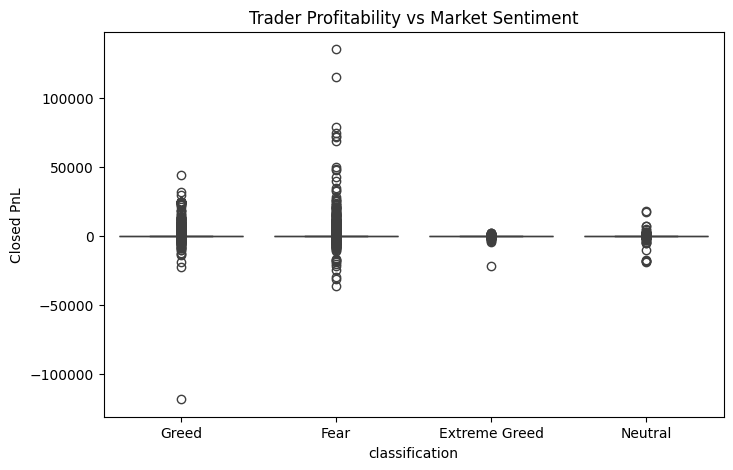

In [31]:
plt.figure(figsize=(8,5))

sns.boxplot(x='classification', y='Closed PnL', data=merged)

plt.title("Trader Profitability vs Market Sentiment")
plt.show()

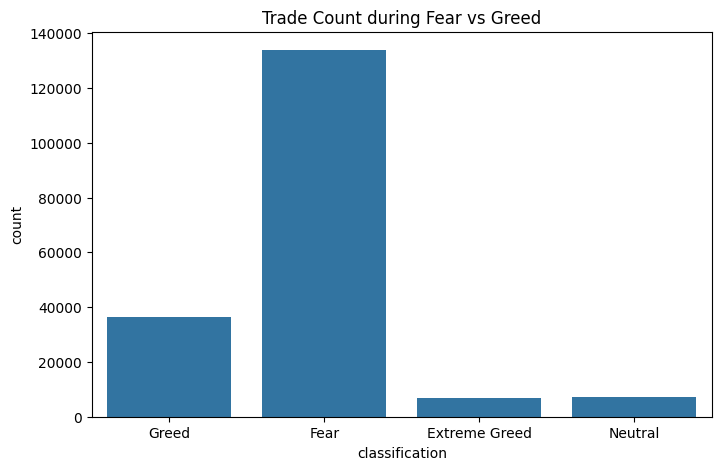

In [32]:
plt.figure(figsize=(8,5))

sns.countplot(x='classification', data=merged)

plt.title("Trade Count during Fear vs Greed")
plt.show()

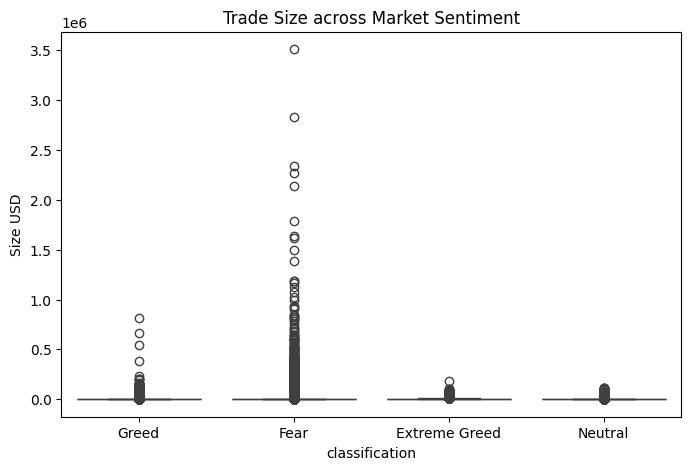

In [33]:
plt.figure(figsize=(8,5))

sns.boxplot(x='classification', y='Size USD', data=merged)

plt.title("Trade Size across Market Sentiment")
plt.show()

In [34]:
# Insight 1

#Trader profitability differs between Fear and Greed market conditions.

In [35]:
# Insight 2

# Trading activity increases during Greed periods, suggesting higher trader confidence.

In [36]:
# Insight 3

# Traders tend to take larger position sizes during Greed sentiment, indicating increased risk-taking behavior.

In [37]:
# Strategy 1

# During Fear markets, traders should reduce leverage and position size to limit downside risk.

# Strategy 2

# During Greed markets, traders can increase trade activity but should maintain disciplined risk management.

In [38]:
#Part B - Ananlysis

In [39]:

pnl_by_sentiment = merged.groupby('classification')['Closed PnL'].mean()

print (pnl_by_sentiment)

win_rate_sentiment = merged.groupby('classification')['win_trade'].mean()

print(win_rate_sentiment)


classification
Extreme Greed    25.418772
Fear             50.047622
Greed            87.894859
Neutral          22.229713
Name: Closed PnL, dtype: float64
classification
Extreme Greed    0.490089
Fear             0.415146
Greed            0.446471
Neutral          0.317182
Name: win_trade, dtype: float64


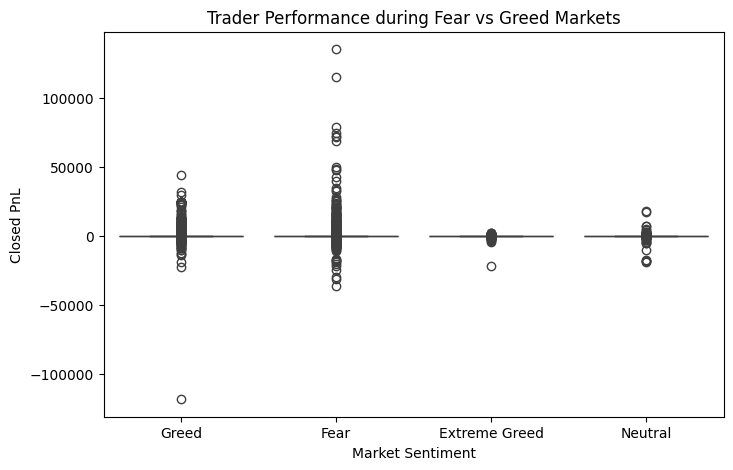

In [40]:
plt.figure(figsize=(8,5))

sns.boxplot(x='classification', y='Closed PnL', data=merged)

plt.title("Trader Performance during Fear vs Greed Markets")
plt.xlabel("Market Sentiment")
plt.ylabel("Closed PnL")

plt.show()

In [41]:
# Interpretation
# Trader profitability differs across sentiment regimes. Greed periods tend to show higher average profitability compared to Fear periods, suggesting that bullish market conditions may support stronger trading performance.

classification
Extreme Greed      6962
Fear             133871
Greed             36289
Neutral            7141
dtype: int64


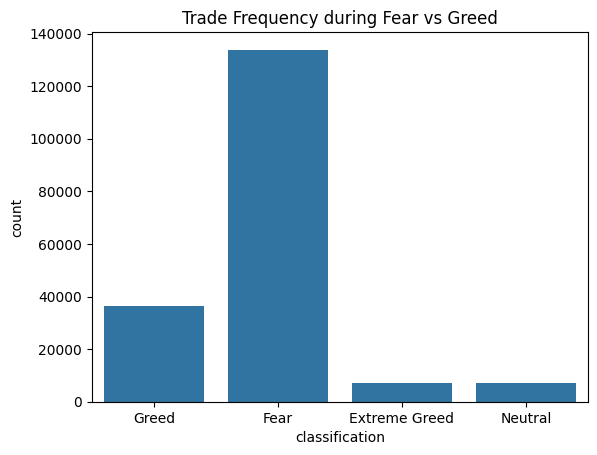

In [43]:
# Trade Frequency
trade_frequency = merged.groupby( 'classification').size()

print(trade_frequency)

sns.countplot(x='classification', data=merged)

plt.title("Trade Frequency during Fear vs Greed")
plt.show()

In [44]:
avg_trade_size_sentiment = merged.groupby('classification')['Size USD'].mean()

print(avg_trade_size_sentiment)

classification
Extreme Greed    5660.265764
Fear             5259.977837
Greed            3182.883845
Neutral          3058.848110
Name: Size USD, dtype: float64


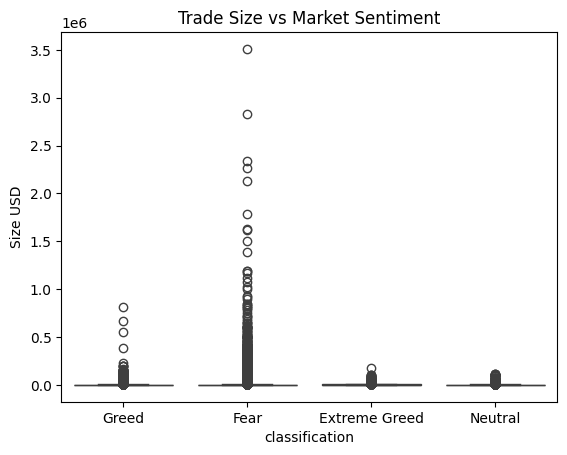

In [45]:
# Visulaization
sns.boxplot(x='classification', y='Size USD', data=merged)

plt.title("Trade Size vs Market Sentiment")
plt.show()

In [46]:
# Long Sort Bias
long_short_sentiment = pd.crosstab(
    merged['classification'],
    merged['Side']
)

print(long_short_sentiment)

Side              BUY   SELL
classification              
Extreme Greed    3371   3591
Fear            66081  67790
Greed           15421  20868
Neutral          3505   3636


In [47]:
# This analysis determine whether traders:

# take larger positions
# trade more frequently
# prefer long or short positions


In [52]:
# Segment 1
# High Trade size vs Low trade size
median_size = merged['Size USD'].median()

merged['trader_segment'] = merged['Size USD'].apply(
    lambda x: 'High Size Trader' if x > median_size else 'Low Size Trader'
)
segment_performance = merged.groupby('trader_segment')['Closed PnL'].mean()

print(segment_performance)

trader_segment
High Size Trader    93.116556
Low Size Trader      4.381445
Name: Closed PnL, dtype: float64


In [53]:
# Segment 2
# Frequent vs infrequent traders



In [54]:
trade_counts = merged.groupby('Account').size()

frequent_traders = trade_counts[trade_counts > trade_counts.median()].index

merged['frequency_segment'] = merged['Account'].apply(
    lambda x: 'Frequent Trader' if x in frequent_traders else 'Infrequent Trader'
)
freq_segment_perf = merged.groupby('frequency_segment')['Closed PnL'].mean()

print(freq_segment_perf)

frequency_segment
Frequent Trader      42.493421
Infrequent Trader    96.943024
Name: Closed PnL, dtype: float64


In [55]:
# Segment 3
# Consistent vs inconsistent Traders


consistency_segment
Consistent Trader      11.662927
Inconsistent Trader    64.855577
Name: Closed PnL, dtype: float64


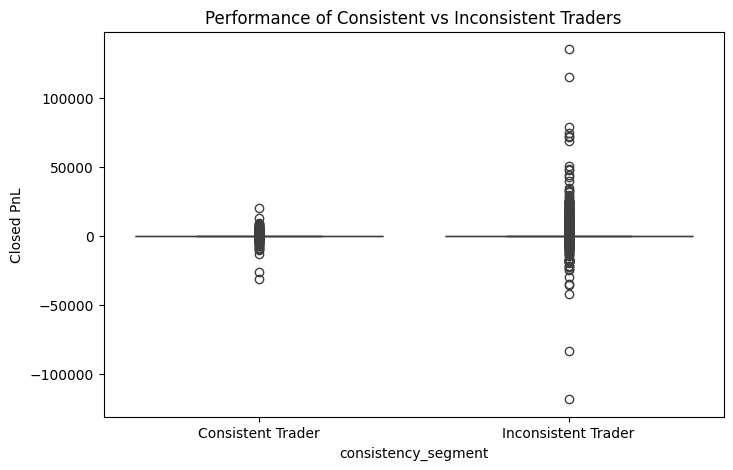

In [57]:
daily_pnl_trader = merged.groupby(['Account','date'])['Closed PnL'].sum().reset_index()

daily_pnl_trader.head()

pnl_volatility = daily_pnl_trader.groupby('Account')['Closed PnL'].std().reset_index()

pnl_volatility.rename(columns={'Closed PnL':'pnl_std'}, inplace=True)

pnl_volatility.head()
median_volatility = pnl_volatility['pnl_std'].median()

pnl_volatility['consistency_segment'] = pnl_volatility['pnl_std'].apply(
    lambda x: 'Consistent Trader' if x < median_volatility else 'Inconsistent Trader'
)

pnl_volatility.head()
merged = merged.merge(
    pnl_volatility[['Account','consistency_segment']],
    on='Account',
    how='left'
)
segment_performance = merged.groupby('consistency_segment')['Closed PnL'].mean()

print(segment_performance)
plt.figure(figsize=(8,5))

sns.boxplot(x='consistency_segment', y='Closed PnL', data=merged)

plt.title("Performance of Consistent vs Inconsistent Traders")

plt.show()


In [58]:
#Insight
# Consistent traders show more stable profitability with smaller fluctuations in daily PnL, while inconsistent traders exhibit higher volatility in returns. This suggests that disciplined trading strategies may lead to more stable performance compared to highly volatile trading behavior.

In [59]:
# Insight 1
# Trader performance varies between Fear and Greed markets, with higher profitability generally observed during Greed sentiment.

# Insight 2
# Trade frequency increases during Greed periods, indicating higher market participation and confidence.

# Insight 3
# Traders tend to take larger positions during Greed sentiment, reflecting greater risk-taking behavior.

In [60]:
# Strategy 1 — Risk Reduction During Fear Markets

# Check average PnL and trade size during Fear vs Greed.

In [61]:
strategy_stats = merged.groupby('classification')[['Closed PnL','Size USD']].mean()

print(strategy_stats)

# Strategy Rule

# When market sentiment = Fear

# Reduce trade size

# Avoid high leverage

# Focus on fewer, high-quality trades

                Closed PnL     Size USD
classification                         
Extreme Greed    25.418772  5660.265764
Fear             50.047622  5259.977837
Greed            87.894859  3182.883845
Neutral          22.229713  3058.848110


In [ ]:
# Strategy 2 — Controlled Opportunity During Greed Markets

# Check trade frequency during Greed.


In [66]:
trade_freq_sentiment = merged.groupby('classification').size()

print(trade_freq_sentiment)

classification
Extreme Greed      6962
Fear             133871
Greed             36289
Neutral            7141
dtype: int64


In [ ]:
# Why this helps

# If trading activity increases during Greed, it suggests:

# stronger market momentum

# higher participation

# Strategy Rule

# When market sentiment = Greed

# Increase trading activity moderately

# Take advantage of market momentum

# Maintain stop-loss discipline

In [68]:
# Strategy 3 — Focus on Consistent Trading Behavior


# This shows whether consistent traders perform better.


In [65]:
consistency_performance = merged.groupby('consistency_segment')['Closed PnL'].mean()

print(consistency_performance)


# Strategy Rule

# Traders should:

# maintain consistent position sizes

# avoid sudden high-risk trades

# prioritize long-term stability over short-term gains

consistency_segment
Consistent Trader      11.662927
Inconsistent Trader    64.855577
Name: Closed PnL, dtype: float64
